In [1]:
library(Seurat)  
library(ggplot2)
library(patchwork)
library(clustree)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.0 but the current version is
4.4.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: ggraph


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry




In [7]:
data_path <- "/gpfs/scratch/ajn8926/spring_semester/scOmics/data/seur_obj_merged.rds"
seur_obj <- readRDS(data_path)
seur_obj = JoinLayers(seur_obj)

table(seur_obj@meta.data$Sample)

tapply(seur_obj@meta.data$nCount_RNA, seur_obj@meta.data$Sample, summary)
tapply(seur_obj@meta.data$nFeature_RNA, seur_obj@meta.data$Sample, summary)

seur_obj@meta.data$percent_mt = PercentageFeatureSet(seur_obj, pattern = "MT-")

tapply(seur_obj@meta.data$percent_mt, seur_obj@meta.data$Sample, summary)
seur_obj = seur_obj[, seur_obj@meta.data$nCount_RNA > 400 & 
                       seur_obj@meta.data$nFeature_RNA > 200 & 
                       seur_obj@meta.data$percent_mt < 30]
gene_boolean = rowSums(LayerData(seur_obj,layer='counts') > 0) >  10
seur_obj = seur_obj[gene_boolean,]
seur_obj[["RNA"]] <- split(seur_obj[["RNA"]], f = seur_obj$Sample)
seur_obj = JoinLayers(seur_obj)
# creates baseline object for use with different hyperparameters 


      GC06B       GC06P       GC06T       GC07B       GC07P       GC07T 
       1440       11458       18108        8584        2950        7306 
      GC08B       GC08P GC08T-site1 
       7966        7678        9323 

$GC06B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    571    3697    4590    5194    5759   43861 

$GC06P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    502    2457    3826    5830    5838   76125 

$GC06T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    2087    3236    5442    5966  102652 

$GC07B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    3768    4680    5096    5760   62059 

$GC07P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    2294    3892    5349    6239   71944 

$GC07T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    503    2007    3713    6434    6615   85319 

$GC08B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    3888    4832    5134    6082   34450 

$GC08P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    505    3456    5004    7201    8698   57527 

$`GC08T-site1`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    500    3016    4874    9336   13770   61383 


$GC06B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     43    1469    1707    1791    1971    6511 

$GC06P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     20    1046    1539    1654    2044    7780 

$GC06T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     23     951    1346    1624    2002    9442 

$GC07B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     26    1501    1744    1787    2004    7360 

$GC07P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     36    1008    1593    1709    2245    7023 

$GC07T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   26.0   983.2  1615.0  1902.2  2361.8  9402.0 

$GC08B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     18    1549    1854    1764    2115    5875 

$GC08P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     33    1088    1696    1965    2649    7926 

$`GC08T-site1`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     19    1303    1827    2464    3561    9233 


$GC06B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.9328  2.5538  3.3240  3.8556  4.3001 95.1890 

$GC06P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.269   4.709  16.403  10.862  99.643 

$GC06T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.278   4.588  12.864   9.084  99.713 

$GC07B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.662   4.486   5.413   5.510  97.512 

$GC07P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   5.678  13.848  18.152  24.067  99.717 

$GC07T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.810   4.881  14.038  12.153  99.390 

$GC08B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.645   4.686   4.750   5.710  97.333 

$GC08P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   5.519  14.818  27.295  37.456  99.713 

$`GC08T-site1`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.963   9.194  18.478  19.677  99.609 


In [8]:
# log normilization 
seur_obj_log <- seur_obj 
seur_obj_log = NormalizeData(seur_obj_log) # every cell's counts gets divided by the total number of counts in that cell and then multiplied by 10k and then logged
seur_obj_log = FindVariableFeatures(seur_obj_log)
seur_obj_log = ScaleData(seur_obj_log)
seur_obj_log = RunPCA(seur_obj_log)
seur_obj_log = FindNeighbors(seur_obj_log)
seur_obj_log = FindClusters(seur_obj_log, algorithm=4,resolution=1,leiden_method='igraph')

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  SPARC, CALD1, IGFBP7, SERPING1, SPARCL1, CAVIN1, NNMT, FSTL1, IFITM3, CNN3 
	   IGFBP4, RBPMS, COL6A1, COL1A2, MGP, COL4A2, MMP2, LAMA4, A2M, PLPP3 
	   COL6A2, DCN, RBMS3, RARRES2, CAV1, TFPI, S100A13, HTRA1, GSN, C1R 
Negative:  GZMB, CCL4, CCR7, GPR183, CD79A, GZMK, MS4A1, FGFBP2, LAG3, IRAG2 
	   BANK1, XCL2, FCGR3A, KLRC2, ENSG00000227240, MZB1, IRF4, LINC02446, JCHAIN, HLA-DPB1 
	   CD38, POU2AF1, KLRC1, VPREB3, HLA-DPA1, CRTAM, TNFRSF18, IGHM, CCL4L2, IGHA1 
PC_ 2 
Positive:  KRT8, KRT18, KRT19, AGR2, LGALS4, TSPAN8, KLF5, EPCAM, PHGR1, S100P 
	   CYP3A5, GPX2, MYH14, AGR3, CLDN4, C19orf33, SPINK1, SHROOM3, S100A14, CYSTM1 
	   MT1G, CLDN3, MUC1, GPRC5A, CLDN7, FXYD3, RAB25, PIGR, VSIG2, PRSS3 
Negative:  LGALS1, IGFBP7, SPARC, COL6A2, TCF4, A2M, CALD1, SPARCL1, SERPING1, HLA-DPA1 
	   MGP, COL1A2, LAMA4, MMP2, DCN, RBMS3, AEBP1, HLA-DPB1, FSTL1, CAV1 
	   

In [ ]:
seur_obj_log <- FindNeighbors(seur_obj_log, dims = 1:20)
for (res in c(0.1, 0.3, 0.5, 0.8, 1.0)) {
  seur_obj_log <- FindClusters(seur_obj_log, resolution = res)
} # something is breaking with the naming convention 

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 64790
Number of edges: 2029213

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9814
Number of communities: 15
Elapsed time: 14 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 64790
Number of edges: 2029213

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9567
Number of communities: 19
Elapsed time: 14 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 64790
Number of edges: 2029213

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9410
Number of communities: 22
Elapsed time: 14 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 64790
Number of edges: 2029213

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9228
Number of communities: 29
Elapsed time: 14 seconds
Modu

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
09:30:10 UMAP embedding parameters a = 0.9922 b = 1.112

09:30:10 Read 64790 rows and found 20 numeric columns

09:30:10 Using Annoy for neighbor search, n_neighbors = 30

09:30:10 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:30:13 Writing NN index file to temp file /tmp/RtmpuikyZB/file29f50c7e089cbb

09:30:13 Searching Annoy index using 1 thread, search_k = 3000

09:30:30 Annoy recall = 100%

09:30:31 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

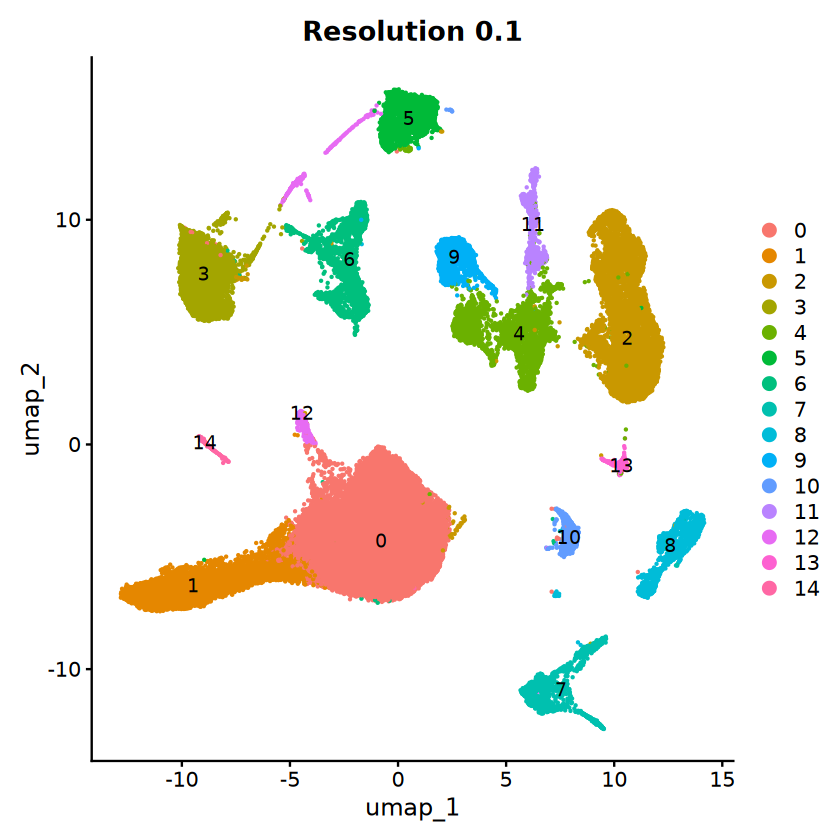

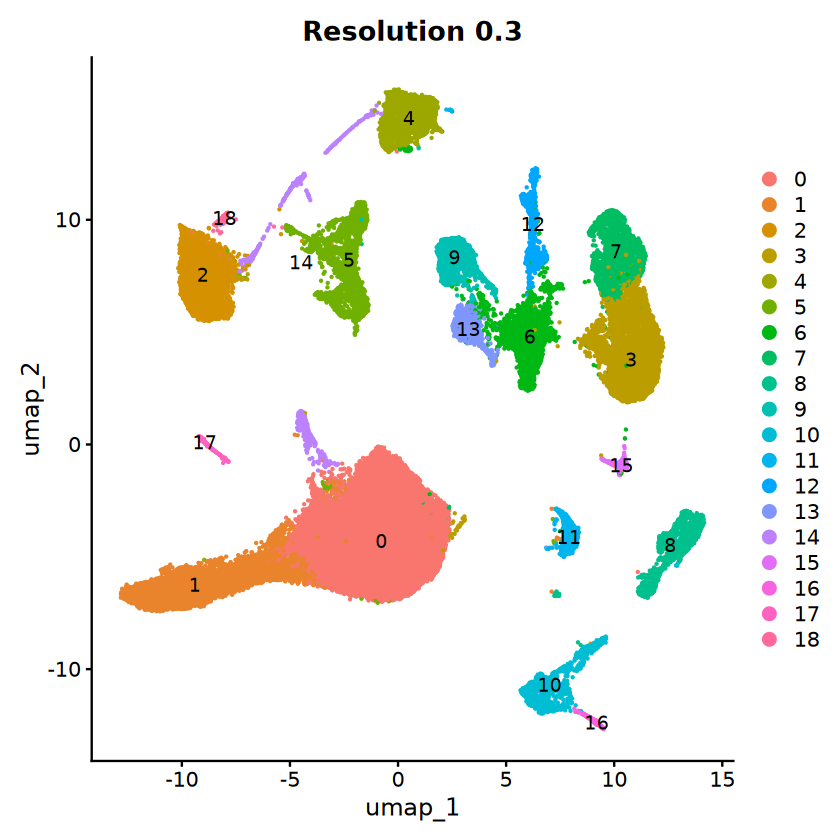

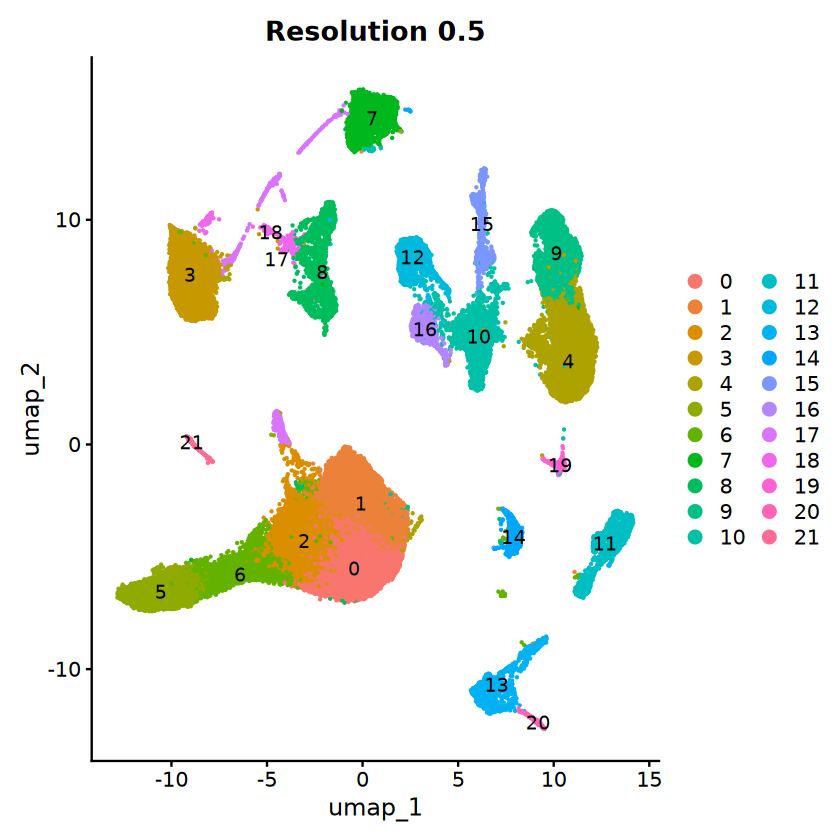

Warning message:
“The following requested variables were not found: RNA_snn_res.1.0”


ERROR: Error in `[.data.frame`(data, , group): undefined columns selected


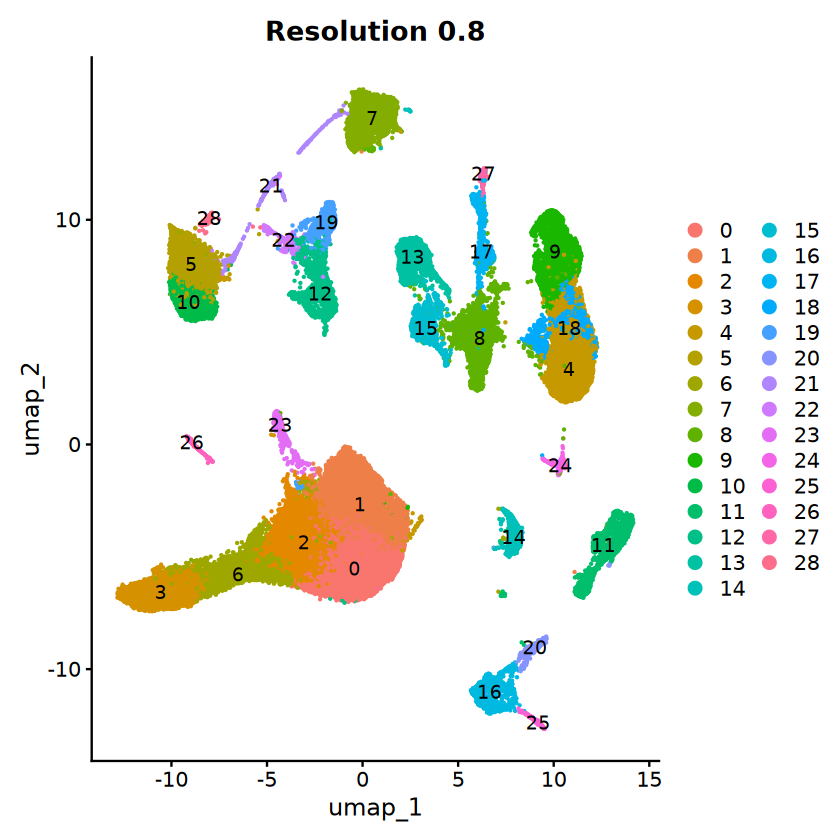

In [ ]:
# umaps by resolution
# seur_obj_log <- RunUMAP(seur_obj_log, dims = 1:20)

# for (res in c("0.1","0.3","0.5","0.8","1.0")) {
#   col <- paste0("RNA_snn_res.", res)
#   print(
#     DimPlot(
#       seur_obj_log,
#       reduction = "umap",
#       group.by = col,
#       label = TRUE
#     ) + ggtitle(paste("Resolution", res))
#   )
# }


In [10]:
# sct normilization
seur_obj_split <- seur_obj
seur_obj_split[["RNA"]] <- split(seur_obj[["RNA"]], f = seur_obj$Sample) # split the object, SRT ran in 12 minues...

seur_sub_sct <- SCTransform(
  seur_obj_split,
  verbose = FALSE
)

seur_sub_sct <- RunPCA(seur_sub_sct) # computes PCA
seur_sub_sct <- FindNeighbors(seur_sub_sct, dims = 1:15) # KNN graph
seur_sub_sct <- FindClusters(seur_sub_sct, resolution = 0.5) # default is Leiden 
seur_sub_sct <- RunUMAP(seur_sub_sct, dims = 1:15) # UMAP for 1 - 15 PCs 

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 776 features requested have not been scaled (running reduction without them): PGC, LIPF, TPSAB1, MUC6, TFF1, MUC5AC, DCN, CXCL14, CHGA, CPA3, GHRL, TFF2, LUM, MGP, C1QB, C1QC, REG1A, TPSB2, PLVAP, COL1A2, SPARCL1, POSTN, IGFBP5, C1QA, CXCL13, APOE, COL3A1, PHGR1, S100A9, ACKR1, MT1G, APOD, GKN1, IGHV1-18, IL1B, S100A8, SFRP2, SERPINE1, BPIFB1, COL1A1, CCN2, MUCL3, TRBV4-1, IGKV3D-20, MFAP4, LCN2, DEPP1, TRBV6-2, TPSD1, IGLV3-19, VWF, CCL14, IGLV4-69, TRBV30, IGHV6-1, AGR2, G0S2, RARRES2, TTR, TRBV12-3, TIMP3, TRBV4-2, CLDN5, TRBV12-4, COL4A1, SOD3, IGFBP6, PSCA, CLEC3B, CXCL8, CCL20, GKN2, CCL11, IGHV2-5, IGHV3-43, CXCL3, IGHV3-74, NDUFA4L2, SLC24A3, TRBV29-1, CCN1, RAMP2, SPINK1, LTF, S100P, GATA2, IGHV1-24, CCL2, COL4A2, NRG1, HDC, ADH1B, IGLV2-23, ADH1C, TRBV6-6, PDGFRA, FBLN1, IGHV3-66, MMP2, IGKV2-28, COL6A3, IGLV3-10, TFF3, VCAN, SDS, FCN1, CXCL2, CD14, PIGR, TRBV15, IGKV3D-15, IGKV

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 64790
Number of edges: 2082689

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9496
Number of communities: 30
Elapsed time: 18 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
13:58:59 UMAP embedding parameters a = 0.9922 b = 1.112

13:58:59 Read 64790 rows and found 15 numeric columns

13:59:00 Using Annoy for neighbor search, n_neighbors = 30

13:59:00 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:59:09 Writing NN index file to temp file /tmp/RtmpHNWJQp/file3c858c64cf0c15

13:59:09 Searching Annoy index using 1 thread, search_k = 3000

13:59:40 Annoy recall = 100%

13:59:41 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

In [11]:
# comparison for log transformation and SCT 
library(viridis)

p_log <- FeaturePlot(
  seur_obj_log,
  features   = c("nCount_RNA","nFeature_RNA","percent_mt"),
  order      = TRUE,
  min.cutoff = "q05",
  max.cutoff = "q95"
) & scale_color_viridis_c(option = "D")  

p_log <- p_log + plot_layout(ncol = 3) +
  ggtitle("LogNormalize – QC gradients")

p_sct <- FeaturePlot(
  seur_sub_sct,
  features   = c("nCount_RNA","nFeature_RNA","percent_mt"),
  order      = TRUE,
  min.cutoff = "q05",
  max.cutoff = "q95"
) & scale_color_viridis_c(option = "D")

p_sct <- p_sct + plot_layout(ncol = 3) +
  ggtitle("SCTransform – QC gradients")

ggsave("qc_gradients_log.png", p_log, width = 12, height = 4, dpi = 300)
ggsave("qc_gradients_sct.png", p_sct, width = 12, height = 4, dpi = 300)


Loading required package: viridisLite

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


The SCTransform UMAP appears moer hetergenious across all categories than the log transformed data. I will use it moving forward 

In [12]:
seur_log <- seur_obj_log        
seur_log <- FindVariableFeatures(seur_log, nfeatures = 2000)
var_log <- VariableFeatures(seur_log)

seur_sct <- seur_obj_split        
seur_sct <- FindVariableFeatures(seur_sct, nfeatures = 2000)
var_sct <- VariableFeatures(seur_sct)

n_overlap  <- length(intersect(var_log, var_sct))
frac_overlap <- n_overlap / 2000

n_overlap # 1405 
frac_overlap # 0.7025

Finding variable features for layer counts

Finding variable features for layer counts.GC06B

Finding variable features for layer counts.GC06P

Finding variable features for layer counts.GC06T

Finding variable features for layer counts.GC07B

Finding variable features for layer counts.GC07P

Finding variable features for layer counts.GC07T

Finding variable features for layer counts.GC08B

Finding variable features for layer counts.GC08P

Finding variable features for layer counts.GC08T-site1



[1] 1405

[1] 0.7025

In [ ]:
saveRDS(seur_obj_log, file = "checkpoint_after_clustree.rds")

In [27]:
seur_sub_sct <- PrepSCTFindMarkers(seur_sub_sct) # valid marker test when there are multiple SCTs

seur_sub_sct$seurat_clusters <- Idents(seur_sub_sct)

marker.df.sct <- FindAllMarkers(seur_sub_sct, group.by = "seurat_clusters")

Found 9 SCT models. Recorrecting SCT counts using minimum median counts: 3289

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20

Calculating cluster 21

Calculating cluster 22

Calculating cluster 23

Calculating cluster 24

Calculating cluster 25

Calculating cluster 26

Calculating cluster 27

Calculating cluster 28

Calculating cluster 29



In [15]:
saveRDS(seur_sub_sct, file = "sct_checkpoint_after_clustree.rds")

In [33]:
marker.df.sct.cluster = split(marker.df.sct, marker.df.sct$cluster)
lapply(marker.df.sct.cluster, head,5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
LTB,0,2.5139913,0.948,0.277,0,0,LTB
LEF1,0,3.7644699,0.728,0.065,0,0,LEF1
TCF7,0,3.7087398,0.735,0.081,0,0,TCF7
NOSIP,0,2.8108511,0.806,0.213,0,0,NOSIP
IL7R,0,0.8465642,0.924,0.333,0,0,IL7R
,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
CD3E.1,0,1.045068,0.924,0.436,0,1,CD3E
ICOS,0,2.349228,0.621,0.151,0,1,ICOS


In [34]:
cluster_map <- c(
  "0"  = "T cells (naive/IL7R+)",
  "1"  = "T cells (CD4 memory/activated)",
  "2"  = "NK cells (FCGR3A/GNLY/FGFBP2)",
  "3"  = "CD8 T cells (cytotoxic)",
  "4"  = "Epithelial (KRT8/18/19+)",
  "5"  = "B cells (MS4A1/CD79A+)",
  "6"  = "T cells (CD4/IL7R+)",
  "7"  = "Epithelial (mucin/PSCA+)",
  "8"  = "Activated CD8 T cells (CCL4/CCL5/CD69)",
  "9"  = "Myeloid/Macrophage",
  "10" = "Epithelial (OLFM4/EPCAM/CLDN3/4)",
  "11" = "Cytotoxic T/NK",
  "12" = "Cytotoxic T/NK",
  "13" = "B cells",
  "14" = "Fibroblasts/Stromal (DCN/COL6A2)",
  "15" = "Epithelial (PSCA/CLDN18)",
  "16" = "Endothelial (PECAM1/VWF/PLVAP)",
  "17" = "Epithelial secretory (PIGR/CXCL17)",
  "18" = "Plasma cells (MZB1/JCHAIN)",
  "19" = "T cells (naive/unstim)",
  "20" = "Mast cells (TPSAB1/KIT/CPA3)",
  "21" = "Plasma cells",
  "22" = "Epithelial (MS4A8/MDK) — check",
  "23" = "B cells",
  "24" = "T cells (naive/LEF1+)",
  "25" = "Cycling/Proliferating",
  "26" = "Myeloid/Macrophage (LST1/AIF1)",
  "27" = "Erythrocytes",
  "28" = "Memory B cells (FCRL5+) — check",
  "29" = "Platelets/Megakaryocytes (PF4/PPBP)"
)

celltype_vec <- cluster_map[as.character(Idents(seur_sub_sct))]
names(celltype_vec) <- colnames(seur_sub_sct)
seur_sub_sct <- AddMetaData(seur_sub_sct, metadata = celltype_vec, col.name = "celltype")

table(seur_sub_sct$celltype, seur_sub_sct$Sample)

                                        
                                         GC06B GC06P GC06T GC07B GC07P GC07T
  Activated CD8 T cells (CCL4/CCL5/CD69)     3   679   821     1    22   170
  B cells                                  150    13     5  1187   142   164
  B cells (MS4A1/CD79A+)                     3  1029  2026    84    56    16
  CD8 T cells (cytotoxic)                    4  1710  2271    17    12    45
  Cycling/Proliferating                      0   128   204     9     7    22
  Cytotoxic T/NK                           170   269   469   704    71   628
  Endothelial (PECAM1/VWF/PLVAP)             0   258   840     0     1   299
  Epithelial (KRT8/18/19+)                   0   477   815     0    12   133
  Epithelial (MS4A8/MDK) — check             0   193   215     0    94    55
  Epithelial (mucin/PSCA+)                   1    24   103     0     5  2778
  Epithelial (OLFM4/EPCAM/CLDN3/4)           0    68    47     0     0     3
  Epithelial (PSCA/CLDN18)         

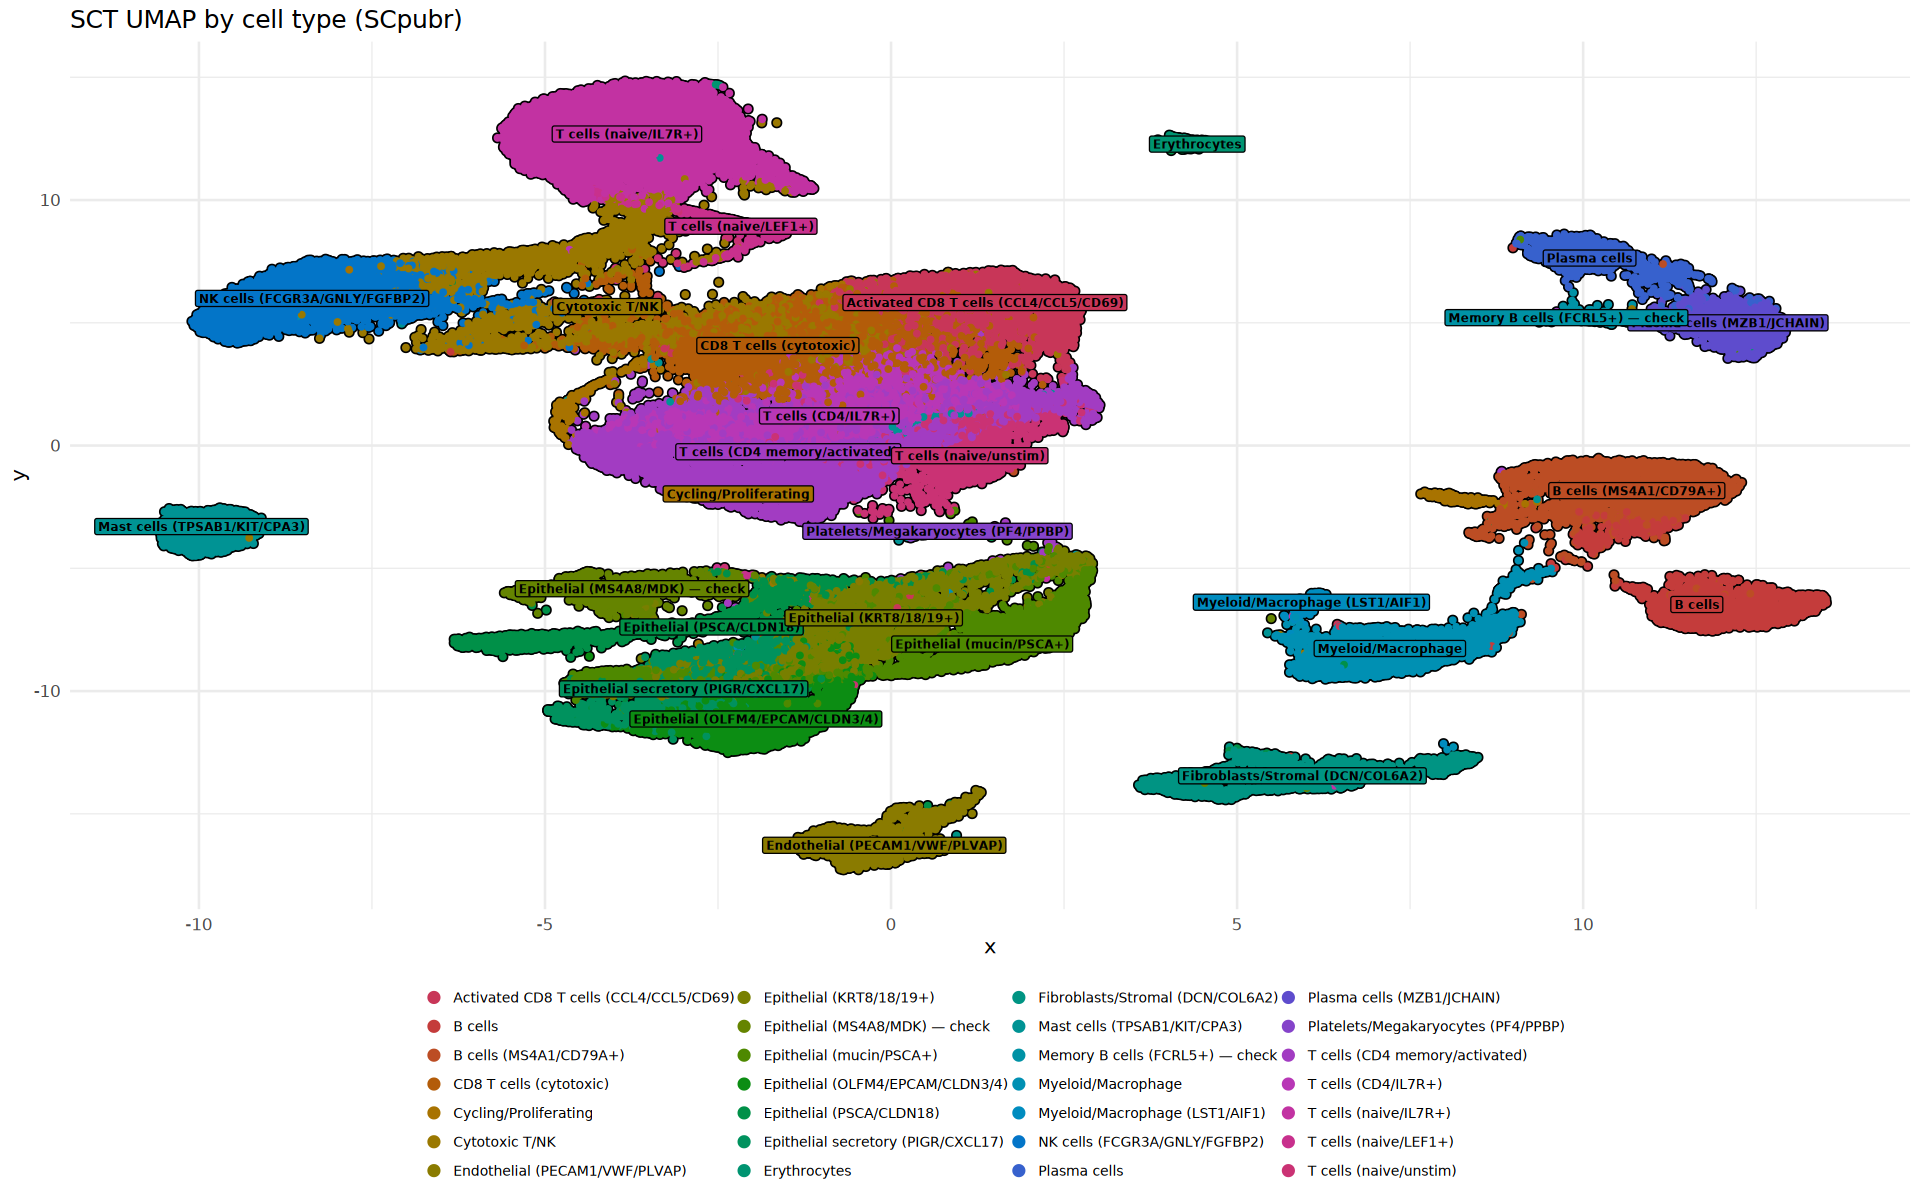

In [ ]:
library(SCpubr)
options(repr.plot.width = 16, repr.plot.height = 10)
p_umap <- SCpubr::do_DimPlot(
  seur_sub_sct,
  reduction = "umap",
  group.by = "celltype",
  label = TRUE,
  label.size = 2.5
  ) +
  ggtitle("SCT UMAP by cell type (SCpubr)") +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.key.size = unit(0.4, "cm"),
    legend.title = element_text(size = 9),
    legend.text = element_text(size = 8)
  ) +
  guides(color = guide_legend(ncol = 4, override.aes = list(size = 2.5, alpha = 1)))

print(p_umap)

In [ ]:

sct_chosen <- readRDS("sct_sweep_results/seur_sct_d20_r0.3.rds")
# or, if still in memory: sct_chosen <- sct  (only if sct is d20_r0.3)
# 2. Table: tissue × cluster distribution
tissue_col <- if ("Sample" %in% names(sct_chosen@meta.data)) "Sample" else "orig.ident"
tab <- table(sct_chosen@meta.data[[tissue_col]], sct_chosen@meta.data$seurat_clusters)
tab_pct <- round(100 * prop.table(tab, margin = 1), 1)
print("Tissue x Cluster (counts)"); print(tab)
print("Tissue x Cluster (% within tissue)"); print(tab_pct)
write.csv(tab, "sct_sweep_results/tissue_cluster_counts_d20_r0.3.csv")
write.csv(tab_pct, "sct_sweep_results/tissue_cluster_pct_d20_r0.3.csv")

[1] "Tissue x Cluster (counts)"
             
                 0    1    2    3    4    5    6    7    8    9   10   11   12
  GC06B         16    8  320  230   64    0    1    0    5    1   18    0    0
  GC06P       1268 1074   14   10  522  117   42  406  312  145  181  111    0
  GC06T       1644 1622   19   26  924  175  219  392  484  556  308  369    0
  GC07B          0    8 1834 1168  589    0   35    0   26   79  154    0    0
  GC07P         35   36    5    0   72  424   17  320   33    9  115    1    0
  GC07T        397  259    6   10   81 1044  143  182  102  146   47  138    0
  GC08B          9    5 1627 1420  306    0    9    0    7   56   49    0    0
  GC08P        415  377    0    2   87   62  658   29   78   95  101   69    4
  GC08T-site1  588  814    3    2   33   66  626   40  264  132   87   63  699
             
                13   14   15   16   17
  GC06B          0    0    0    0    0
  GC06P         92   67   85   47    0
  GC06T        166  202   92   39

## Annotation

prof will give you annotation list. says pulling cell type markers from data base is tricky because the db uses healthy cells and we have cancer cells

## Notes

make the same vis for tissue and for pateint in terms of Umaps, we want patients to mix, we want all the cell types in the same cluster together 

SCpubr is a package that makes SC plots prettier, very good baseline, plots umap points randomly so there is no massive overlap, similar to seurat shuffle argument   


